In [2]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
# # REWRITE TO WORK WITH NETCDF FILES!
# def read_mat_data(filepath):
#     import scipy.io
    
#     rd = scipy.io.loadmat(filepath) # load the mat file
#     PDATA = rd['PDATA']
#     TWT = rd['TWT']
    
#     return PDATA, TWT

In [4]:
datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/'
ncfiles = glob.glob(datapath+'*_v1.nc')
ncfiles.sort()
ncfiles

['/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/bigDriftWofNorthline_v1.nc']

### sky calibration

In [16]:
# Compile all skycal sections:
files_skycal = glob.glob('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/*_skycal_idxs.csv')
radargram_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/pdata/'

skycal_traces = []
for file in files_skycal:
    skycal_df = pd.read_csv(file); skycal_idxs = skycal_df.skycal_idxs # read in skycal indexes
    fname = file.split('/')[-1]
    print(fname)

    # read radargram data
    radargram_file = radargram_folder+fname[:-16]+'.mat'
    if os.path.exists(radargram_file):
        [PDATA, TWT] = read_mat_data(radargram_file) 
         
    
        if len(skycal_idxs) > 0:
            print(fname[:-16]+'.mat')
    
        # grab skycal traces
        for i in skycal_idxs:
            skycal_traces.append(PDATA[:,i-1]) # grab the skycal trace

pdriftzigzag_8_PDATA_skycal_idxs.csv
pdriftzigzag_8_PDATA.mat


IndexError: index 511 is out of bounds for axis 1 with size 511

In [12]:
# show all skycal sections
plt.figure(figsize=(14,5))
plt.imshow(np.stack(skycal_traces,axis=1),vmin=np.percentile(PDATA,50), vmax=np.percentile(PDATA,100), cmap='Greys_r')
plt.show()

ValueError: need at least one array to stack

<Figure size 1008x360 with 0 Axes>

In [ ]:
# calculate the average skycal section as a vector
skycal_avg_vec = np.nanmean(np.stack(skycal_traces,axis=1),axis=1).reshape(8192,1)
plt.figure(figsize=(14,5))
plt.imshow(np.tile(skycal_avg_vec, np.stack(skycal_traces,axis=1).shape[1]),
           vmin=np.percentile(skycal_avg_vec,50),vmax=np.percentile(skycal_avg_vec,100),cmap='Greys_r')
plt.show()

In [ ]:
# save skycal vector to CSV
pd.DataFrame(list(zip(skycal_avg_vec)),
             columns=['skycal_mean_vals']).to_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/skycal_mean.csv')

## Processing functions

In [5]:
def subtract_skycal(RADARGRAM, skycal_avg_vec):
    # INPUTS:
    # - radargram
    # - column vector of average skycal values
    # OUTPUT:
    # - skycal subtracted radargram

    skycal_array = np.tile(skycal_avg_vec, RADARGRAM.shape[1]) # create a skycal array of the same shape as the rd
    print(skycal_array.shape)

    skycal_corrected = RADARGRAM-skycal_array # subtract the skycal values
    
    return skycal_corrected

def apply_range_gain(RADARGRAM):
    ylen = RADARGRAM.shape[0] # grab the ydimension
    yvec = np.arange(1,ylen+1) # create a vector starting at 1 through the maximum index (ylen)

    # different shapes of range multiplier vector:
    # range_multiplier = np.array(1/(yvec**2))
    # range_multiplier = np.array(1/np.sqrt(yvec))
    # range_multiplier = np.array(np.flip(yvec)/np.max(yvec)) # linear
    range_multiplier = np.array(np.log(np.flip(yvec))) # logarithmic
    plt.plot(range_multiplier); plt.title('range multiplier')
    plt.show()

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,14)) # initialize a figure to show before and after
    ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,100), cmap='Greys_r')
    ax1.set_title("before range gain correction")

    RADARGRAM = RADARGRAM * np.transpose([range_multiplier]) # CORRECTION

    # show after range gain correction
    ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax2.set_title("after range gain correction")
    plt.show()

    return RADARGRAM

def remove_flats(RADARGRAM, minval, noise_thresh=1.0):
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(6,6)) # initialize a figure to show before and after
    ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax1.set_title("before removing flat reflectors")
    
    yidxs = np.arange(0,RADARGRAM.shape[0]) # rows
    for yidx in yidxs:
        row = RADARGRAM[yidx,:] # grab the row
        # plt.plot(row); plt.show() # visualize (optional)

        # if the full noise range is less than the threshold, remove the reflector 
        if (np.nanmax(row) - np.nanmin(row)) <= noise_thresh: # inclusive noise threshold
            RADARGRAM[yidx,:] = np.ones(RADARGRAM.shape[1])*minval # replace original values with the minval in the radargram
    # show before and after
    ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax2.set_title("after removing flat reflectors")
    plt.show()

    return RADARGRAM

In [22]:
 # set path to the FMCW mat files - rewrite for netCDF
filespath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/'
files = glob.glob(filespath+'p*PDATA.mat')
files.sort()

In [23]:
# read in skycal vector
skycal_df = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/skycal_mean.csv').skycal_mean_vals
skycal_avg_vec = []
for sc in skycal_df:
    sc_float = float(sc[1:-1])
    skycal_avg_vec.append(sc_float)
skycal_avg_vec = np.array(skycal_avg_vec,dtype=float).reshape(len(skycal_avg_vec),1) # reshape into a column vector


# read in all the radargrams
radargrams = []; xs = []; ys = []
for filepath in files:
    print(filepath)
#     [PDATA, TWT, x, y, z, skycal_idx, trace_idx] = read_mat_data_xyz(filepath)
    [PDATA, TWT, x, y, z, skycal_idx, trace_idx] = read_rd_ncfile(filepath)
    halfidx = PDATA.shape[0]
    TWT = TWT[0][halfidx:]

    # subtract skycal
    rd_skycal = subtract_skycal(PDATA, skycal_avg_vec)
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(6,6))
    ax1.imshow(PDATA, vmin=np.percentile(PDATA,50), vmax=np.percentile(PDATA,100), cmap='Greys_r')
    ax2.imshow(rd_skycal, vmin=np.percentile(rd_skycal,50), vmax=np.percentile(rd_skycal,100), cmap='Greys_r')
    ax1.set_title('original rd'); ax2.set_title('skycal correction')
    plt.show()

    # remove flat layers
    rd1 = remove_flats(rd_skycal, np.percentile(rd_skycal,50), np.std(rd_skycal)*2) # use the std of the rd as the noise threshold 

    # save
    radargrams.append(rd1)
    xs.append(x); ys.append(y)

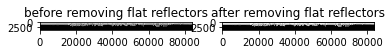

In [18]:
# FOR NC FILE
datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/'
ncfiles = glob.glob(datapath+'*_v1.nc')
ncfiles.sort()
ncfiles

radargrams = []; xs = []; ys = []
for file in ncfiles:
    ds = xr.open_dataset(file, engine="netcdf4")
    rd = ds.PDATA; x = ds.UTMx; y = ds.UTMy
    
    rd1 = remove_flats(rd, np.percentile(rd,50), np.std(rd)*2)
    radargrams.append(rd1); xs.append(x); ys.append(y)


## Stitch them together horizontally

In [19]:
# horzontal concatenate
all_rd = np.hstack(radargrams) 
radargrams = [] # ERASE TO SAVE SPACE

# flatten and stack x,y coordinates
xs_flattened = np.array([]); ys_flattened = np.array([])
for xi in xs:
    xs_flattened = np.append(xs_flattened, xi)
for yi in ys:
    ys_flattened = np.append(ys_flattened, yi)

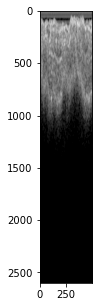

In [30]:
# show all radargrams stacked and test subsets
plt.figure(figsize=(14,5))
plt.imshow(all_rd[500:3200,13500:14000],vmin=np.percentile(all_rd,50), 
           vmax=np.percentile(all_rd,100), cmap='Greys_r')
plt.show()

## Subset horizontally and vertically

In [24]:
# crop horizontally and vertically
xmin_idx = 13500; xmax_idx = 80000
hmin_idx = 3200 # keep everything above this vertical index

all_rd = all_rd[:hmin_idx,xmin_idx:xmax_idx]
# skycal_avg_vec = skycal_avg_vec[:hmin_idx,xmin_idx:xmax_idx] # keep upper portion of skycal as well
xs_flattened = xs_flattened[xmin_idx:xmax_idx]
ys_flattened = ys_flattened[xmin_idx:xmax_idx]

In [25]:
# save coordinates
np.save(datapath+'preprocessed_stitched_rd_xs.npy', xs_flattened)
np.save(datapath+'preprocessed_stitched_rd_ys.npy', ys_flattened)

In [26]:
# save array
np.save(datapath+'preprocessed_stitched_rd.npy', all_rd)